# Agents

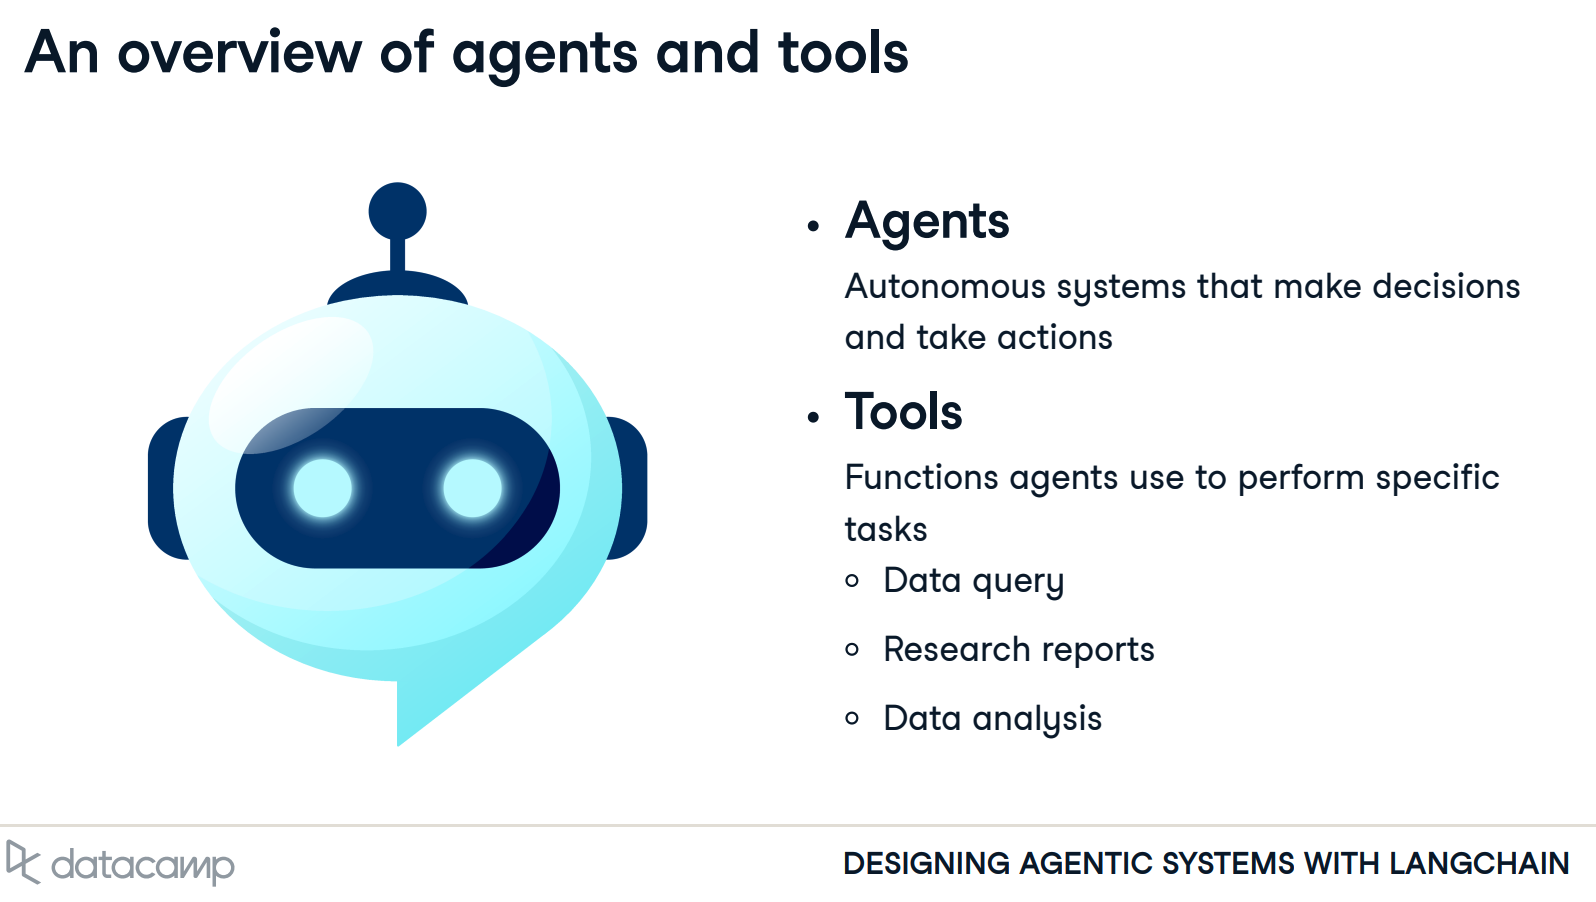

The Agent is at its core an LLM, which consumes tools to perform a task. In this course we will use Langchain, which is a Framework to build AI agents using components such as:

- LLMS
- Prompts
- Tools
- APIs

## ReAct Agents

Agents can Reason about a problem, then Act. This agentic framework is called ReAct

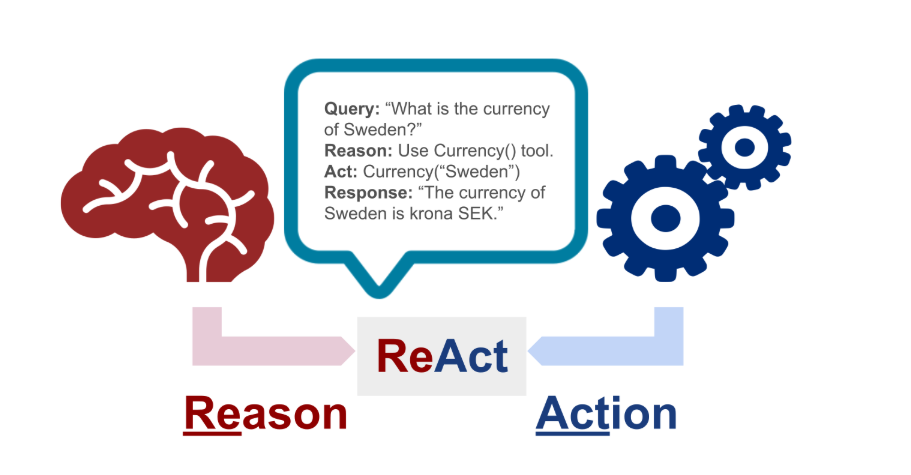

## Expanding agents with LangGraph

Langgrapgh can enhance tools even further by structuring tasks in workflows called graphs

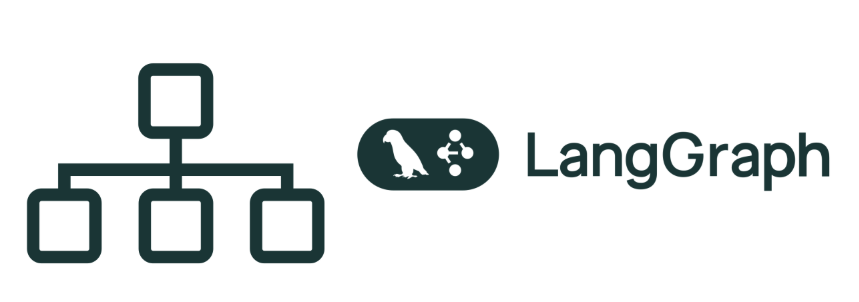

In these graphs

- The **tasks** are called **nodes**
- The **nodes** are connected by rules called **edges**

For example, A database query node identifies the correct document ID, saves it to the State, and an edge routes the workflow to the document retrieval node, which uses the ID from the State to fetch the text.

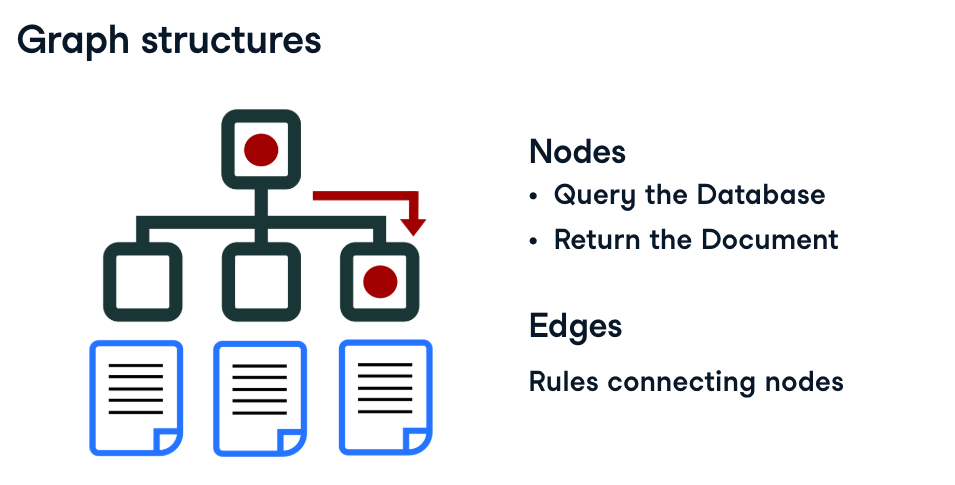

In [1]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool
from langchain.agents import create_agent

# Load variables from .env into the system environment
load_dotenv() 

# LangChain automatically detects "ANTHROPIC_API_KEY" from the environment
model = ChatAnthropic(model="claude-haiku-4-5")

# Define the tool
@tool
def calculator(expression: str) -> str:
    """
    Evaluates a mathematical expression string and returns the result.
    Useful for solving math problems like (2+8)*9.
    """
    try:
        # Note: In production, use a safer math library than eval()
        return str(eval(expression))
    except Exception as e:
        return f"Error: {str(e)}"

# Put the tool in a list
tools = [calculator]

# Create the agent
agent = create_agent(model, tools)

# Create a query
query = "What is (2+8) multiplied by 9?"
response = agent.invoke({"messages": [("human", query)]})

# Print the response
print(response['messages'][-1].content)

(2+8) multiplied by 9 equals **90**.

Here's the breakdown:
- 2 + 8 = 10
- 10 × 9 = 90


did it actually use the tool? let's see

In [3]:
from pprint import pprint

# This will print the response dictionary with nice indentation
pprint(response)

{'messages': [HumanMessage(content='What is (2+8) multiplied by 9?', additional_kwargs={}, response_metadata={}, id='620262bf-87ce-4b5e-b9fa-8f890e244a6a'),
              AIMessage(content=[{'id': 'toolu_01NefeK73ZaFsdKohQHYbLX5', 'caller': {'type': 'direct'}, 'input': {'expression': '(2+8)*9'}, 'name': 'calculator', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01Kwbfj7Y7P3a4PiqNgWRESW', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 588, 'output_tokens': 57, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019cc145-8d26-7893-9523-b43de9380ac9-0', tool_calls=[{'name': 'calculator', 'args': {'expression':

# Building Custom Tools

Note that for a tool to be usable by an LLM it has to contain some main parts:

### 1. The Name (The Identifier)

The name should be **unique and semantic**. The LLM uses the name as a quick reference.

* **Bad:** `func1`, `get_data`, `run_query`.
* **Good:** `get_weather_forecast`, `query_customer_database`, `calculate_mortgage_payment`.
* **Pro Tip:** Use underscores or CamelCase consistently, and make it sound like an action.

### 2. The Description (The "Instruction Manual")

This is the most critical part. The LLM reads this to decide **if** it should use the tool. If your agent isn't calling a tool when it should, your description is likely too vague.

* **What to include:**
* **Purpose:** What does this tool actually do?
* **When to use it:** "Use this tool when the user asks for historical stock prices..."
* **When NOT to use it:** "...do not use this for real-time price alerts."
* **Output format:** Tell the LLM what kind of data it will get back (e.g., "Returns a JSON list of products").



### 3. The Input Schema (The Arguments)

In LangChain, this is usually defined via **Pydantic** or a **JSON Schema**. You must be explicit about the data types.

* **Parameter Names:** Should be descriptive (e.g., `zip_code` instead of `z`).
* **Parameter Descriptions:** Describe what each argument expects. For example, if a date is required, specify the format: `"date (YYYY-MM-DD)"`.
* **Required vs. Optional:** Clearly define which fields the LLM *must* provide and which have default values.

### 4. The Output (The Observation)

What the function returns is what the agent "sees" next.

* **Text-Friendly:** LLMs process text best. If your function returns a massive, messy Python object, the agent might get confused or run out of tokens.
* **Error Handling:** If the tool fails (e.g., a 404 error from an API), return a **descriptive error string** like `"Error: Customer ID not found. Please verify the ID and try again."` rather than just crashing the code. This allows the agent to "reason" about the error and potentially try a different approach.

In [4]:
import math
from langchain.tools import tool
from pydantic import BaseModel, Field

# 1. Define the Input Schema (The "Arguments")
class HypotenuseInput(BaseModel):
    side_a: float = Field(description="The length of the first leg of the right triangle.")
    side_b: float = Field(description="The length of the second leg of the right triangle.")

# 2. Define the Tool with a clear Name and Description
@tool("calculate_hypotenuse", args_schema=HypotenuseInput)
def calculate_hypotenuse(side_a: float, side_b: float) -> str:
    """
    Calculates the length of the hypotenuse for a right-angled triangle 
    given the lengths of the other two sides (legs).
    Use this tool whenever a user asks for the longest side of a right triangle.
    """
    try:
        # 3. The Logic (The "Action")
        hypotenuse = math.sqrt(side_a**2 + side_b**2)
        
        # 4. The Output (The "Observation")
        return f"The hypotenuse is {hypotenuse:.2f}"
    except Exception as e:
        return f"Error calculating hypotenuse: {str(e)}"
    
tools = [calculate_hypotenuse]

# Create the agent
agent = create_agent(model, tools)

# Create a query
query = "What is the hypotenuse length of a triangle with side lengths of 10 and 12?"
response = agent.invoke({"messages": [("human", query)]})

# Print the response
print(response['messages'][-1].content)

The hypotenuse of a right triangle with side lengths of 10 and 12 is **15.62** units (rounded to two decimal places).

This is calculated using the Pythagorean theorem: c² = a² + b², where c is the hypotenuse. In this case: c² = 10² + 12² = 100 + 144 = 244, so c = √244 ≈ 15.62.


In [5]:
from pprint import pprint

# This will print the response dictionary with nice indentation
pprint(response)

{'messages': [HumanMessage(content='What is the hypotenuse length of a triangle with side lengths of 10 and 12?', additional_kwargs={}, response_metadata={}, id='aa130a1a-c83c-4846-8b34-e0f34b1857a1'),
              AIMessage(content=[{'id': 'toolu_01TzwYUBBiNCzHbx8BFPpSsd', 'caller': {'type': 'direct'}, 'input': {'side_a': 10, 'side_b': 12}, 'name': 'calculate_hypotenuse', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01Wvw58Kq7St165aVNhtmijg', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 676, 'output_tokens': 78, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019cc148-dba3-7873-8d9f-d27e0f1b50b4-0',

# Conversation History

First, let's start exploring a simple interaction. Query -> Response

In [7]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool
from langchain.agents import create_agent

@tool
def rectangle_area(length: float, width: float) -> str:
    """
    Calculates the area of a rectangle given its length and width.
    Useful for solving geometry problems related to rectangles.
    """
    try:
        area = length * width
        return f"The area of the rectangle is {area:.2f}"
    except Exception as e:
        return f"Error calculating area: {str(e)}"

# LangChain automatically detects "ANTHROPIC_API_KEY" from the environment
model = ChatAnthropic(model="claude-haiku-4-5")

agent = create_agent(model, [rectangle_area])

query = "What is the area of a rectangle with length 5 and width 3?"

response = agent.invoke({"messages": [("human", query)]})

# Define and print the input and output messages
print({
    "input": query,
    "output": response['messages'][-1].content
})

{'input': 'What is the area of a rectangle with length 5 and width 3?', 'output': 'The area of a rectangle with length 5 and width 3 is **15 square units**.'}


In [4]:
def did_the_agent_use_tools(response: dict) -> bool:
    """
    Evaluates a LangChain/LangGraph response dictionary to determine 
    if the agent utilized any tools.
    """
    # Extract the list of messages, defaulting to an empty list if not found
    messages = response.get('messages', [])
    
    for msg in messages:
        # Check 1: Did the system record a tool execution?
        # LangChain message objects have a 'type' attribute ('human', 'ai', 'tool')
        if getattr(msg, 'type', None) == 'tool':
            return True
        
        # Check 2: Did the AI request a tool call?
        # AIMessages have a 'tool_calls' attribute when they decide to use a tool
        if getattr(msg, 'tool_calls', []):
            return True
            
    return False

In [ ]:
did_the_agent_use_tools(response)

True

Now, let's expand it to follow up questions.

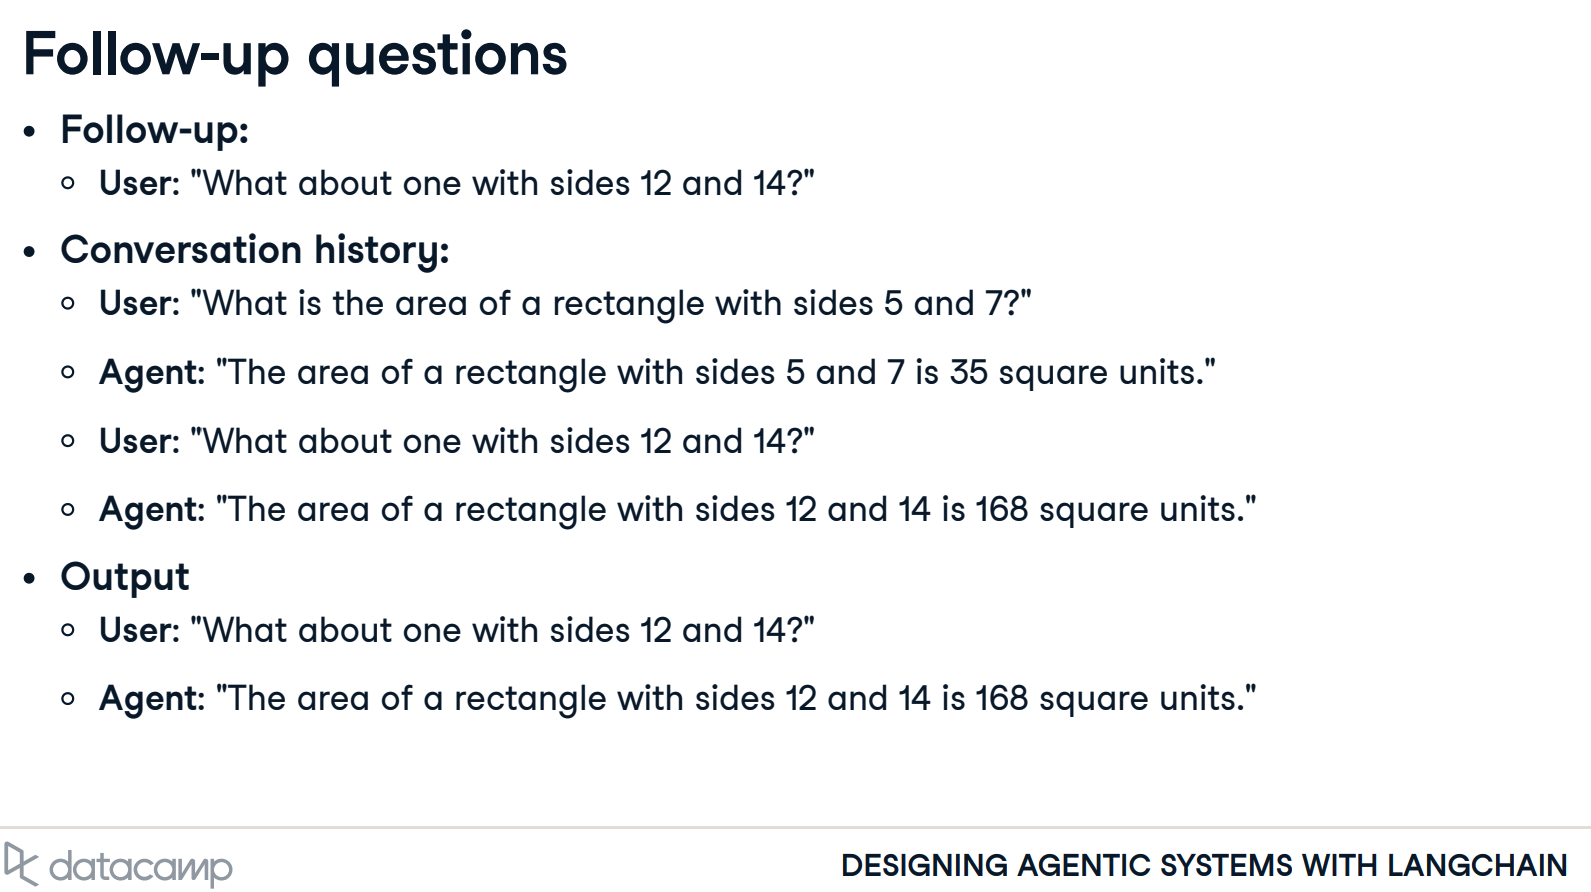

In [15]:
from langchain_core.messages import HumanMessage, AIMessage

message_history = response["messages"]

new_query = "What about one with sides 12 and 14?"

response = agent.invoke({"messages": message_history + [("human", new_query)]})

In [18]:
# Updated filtering logic
filtered_messages = []

for msg in response["messages"]:
    # 1. Check if it's the right message type
    if isinstance(msg, (HumanMessage, AIMessage)):
        content = msg.content
        
        # 2. If content is a string, check if it's not empty
        if isinstance(content, str) and content.strip():
            filtered_messages.append(msg)
            
        # 3. If content is a list (tool call), it's still a valid AI message 
        # You might want to keep these to see the agent's "thought" process
        elif isinstance(content, list) and len(content) > 0:
            filtered_messages.append(msg)

from pprint import pprint
pprint({
    "user_input": new_query,
    "agent_output": [f"{msg.__class__.__name__}: {msg.content}" for msg in filtered_messages]
})

{'agent_output': ['HumanMessage: What is the area of a rectangle with length 5 '
                  'and width 3?',
                  "AIMessage: [{'id': 'toolu_01Tk5x72WMyEEfNAmswpG1Ea', "
                  "'caller': {'type': 'direct'}, 'input': {'length': 5, "
                  "'width': 3}, 'name': 'rectangle_area', 'type': 'tool_use'}]",
                  'AIMessage: The area of a rectangle with length 5 and width '
                  '3 is **15 square units**.',
                  'HumanMessage: What about one with sides 12 and 14?',
                  "AIMessage: [{'id': 'toolu_01HeFvsGAAfti6nxFySCZmE9', "
                  "'caller': {'type': 'direct'}, 'input': {'length': 12, "
                  "'width': 14}, 'name': 'rectangle_area', 'type': "
                  "'tool_use'}]",
                  'AIMessage: The area of a rectangle with sides 12 and 14 is '
                  '**168 square units**.'],
 'user_input': 'What about one with sides 12 and 14?'}


# Building Custom Chatbots

Custom agents are built defining a graph and agent states that manage chatbot workflows.

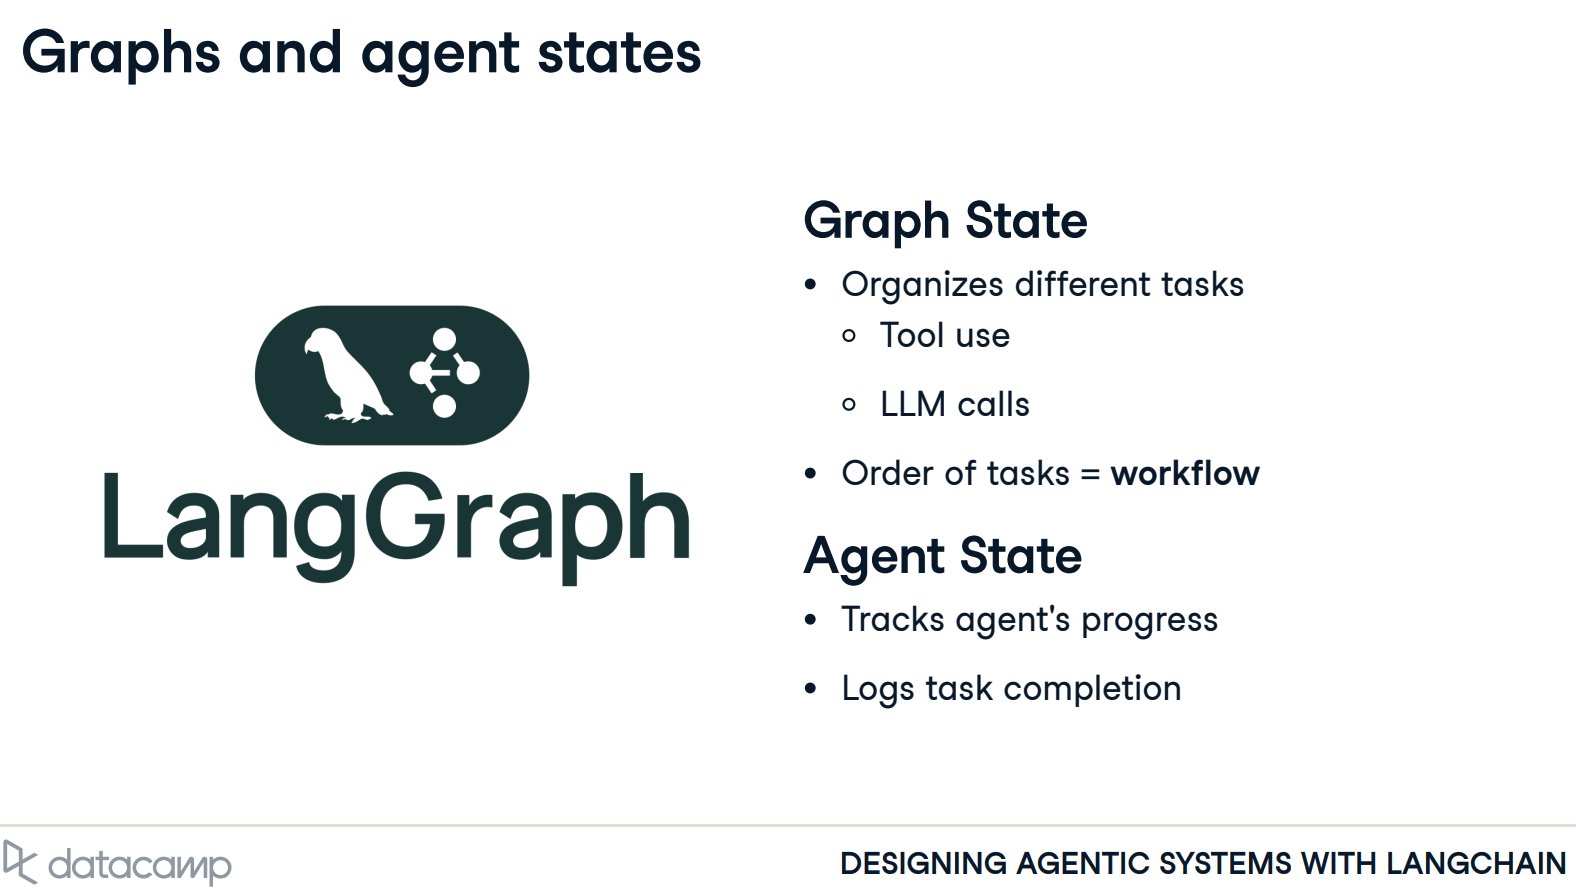

Let's build an education chatbot that uses an LLM to answer questions

In [1]:
from langchain_anthropic import ChatAnthropic
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Define the llm
llm = ChatAnthropic(model="claude-haiku-4-5")

# Define the State
class State(TypedDict):
    
    # Define messages with metadata
    messages: Annotated[list, add_messages]

# Initialize StateGraph
graph_builder = StateGraph(State)

# Define chatbot function to respond with the model
def chatbot(state: State):
    return {"messages":
    [llm.invoke(state["messages"])]}

# Add chatbot node to the graph
graph_builder.add_node("chatbot", chatbot)

# Define the start and end of the conversation flow
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph to prepare for execution
graph = graph_builder.compile()

# Define a function to execute the chatbot with a given user input
def stream_graph_updates(user_input: str):
    
    # Start streaming events from the graph with the user's input
    for event in graph.stream({"messages": [("user", user_input)]}):

        # Retrieve and print the chatbot node responses
        for value in event.values():
            print("Agent", value["messages"])

# Define the user query and run the chatbot
user_query = "Who is Diomedes Diaz?"
stream_graph_updates(user_query)

Agent [AIMessage(content="I don't have enough context to give you a definitive answer, as there are several people with that name. Could you provide more details, such as:\n\n- Their profession (politician, athlete, artist, etc.)\n- Time period or era they're from\n- Country or region they're associated with\n- Any notable achievements or events\n\nWith more information, I'd be happy to help identify who you're asking about.", additional_kwargs={}, response_metadata={'id': 'msg_016k94Vva9ZGnoveaWZy7zQn', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 17, 'output_tokens': 91, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019ccf05-

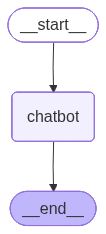

In [2]:
from IPython.display import Image, display

Image, display

try:
    display(Image(graph.get_graph()
    .draw_mermaid_png()))
except Exception as e:
    print("Additional dependencies required")

# Adding external tools with langgraph

restart your session so that you can define your graph again

In [1]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_anthropic import ChatAnthropic
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Define the llm
llm = ChatAnthropic(model="claude-haiku-4-5")

# Define the State
class State(TypedDict):
    
    # Define messages with metadata
    messages: Annotated[list, add_messages]

# Initialize StateGraph
graph_builder = StateGraph(State)

# Define the tools
api_wrapper = WikipediaAPIWrapper(top_k_results=1)
wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper)
tools = [wikipedia_tool]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages":
            [llm_with_tools.invoke(
                state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[wikipedia_tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot", tools_condition)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
# graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

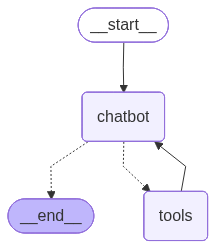

In [2]:
from IPython.display import Image, display

Image, display

try:
    display(Image(graph.get_graph()
    .draw_mermaid_png()))
except Exception as e:
    print("Additional dependencies required")

## Adding memory and conversation

In [3]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

def stream_memory_responses(user_input: str):
    config = {"configurable": {"thread_id": "single_session_memory"}}

    for event in graph.stream({"messages": [("user", user_input)]}, config):

        for value in event.values():
            if "messages" in value and value["messages"]:
                print("Agent:", value["messages"])

stream_memory_responses("What is the Colosseum?")
stream_memory_responses("Who built it?")

Agent: [AIMessage(content=[{'id': 'toolu_01MiguXxj5SsyZKazYucH5of', 'caller': {'type': 'direct'}, 'input': {'query': 'Colosseum'}, 'name': 'wikipedia', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01YSuGkD8MMESdjuUhdctJaY', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 605, 'output_tokens': 55, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019ccf35-cd74-7210-bd99-f8c034875be6-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Colosseum'}, 'id': 'toolu_01MiguXxj5SsyZKazYucH5of', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 605, 'output_tokens': 55, 'total_tokens'

# Multiple Tool Chatbot

Now that our chatbot can use tools, let's setup an agent with multiple tools who can decide which one to use

In this architecture, we will build two workflow functions

- **should_continue:** Decides whether to call tools or end the conversation if there is no tool call in the last message
- **call_model:** Dynamic tool caller that returns a tool response if a tool call is present

In [ ]:
from typing import Annotated
from langchain_anthropic import ChatAnthropic
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.messages import AIMessageChunk

# 1. Define the LLM
llm = ChatAnthropic(model="claude-haiku-4-5")

# 2. Define the custom tools
@tool
def date_checker(date: str) -> str:
    """Provide a list of important historical events that occurred on the given date in any format."""
    try:
        # Using the LLM to generate the historical events
        answer = llm.invoke(f"List important historical events that occurred on {date}.")
        return answer.content
    except Exception as e:
        return f"Error: {str(e)}"
    
@tool
def check_palindrome(text: str) -> str:
    """Check if the given text is a palindrome (reads the same backward and forward)."""
    try:
        cleaned_text = ''.join(char.lower() for char in text if char.isalnum())
        is_palindrome = cleaned_text == cleaned_text[::-1]
        return f"'{text}' is a palindrome." if is_palindrome else f"'{text}' is not a palindrome."
    except Exception as e:
        return f"Error: {str(e)}"

# 3. Define the Wikipedia tool
api_wrapper = WikipediaAPIWrapper(top_k_results=1)
wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

# 4. Combine all tools and bind to the LLM
tools = [wikipedia_tool, date_checker, check_palindrome]
tool_node = ToolNode(tools=tools)

model_with_tools = llm.bind_tools(tools)

# 5. Define the simplified node function
def call_model(state: MessagesState):
    # The LLM automatically reads the messages state and decides if it needs to output text or a tool call
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# 6. Build the workflow using the built-in MessagesState
workflow = StateGraph(MessagesState)

# Set up the nodes
workflow.add_node("chatbot", call_model)
workflow.add_node("tools", tool_node)

# Set up the edges
workflow.add_edge(START, "chatbot")

# Use LangGraph's prebuilt tools_condition to handle the routing logic automatically
workflow.add_conditional_edges("chatbot", tools_condition)

workflow.add_edge("tools", "chatbot")

# 7. Set up memory checkpointing and compile
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

## Follow Up questions with Multi Tools

In [3]:
def user_agent_multiturn(queries):
    for query in queries:
        print(f"User: {query}")
        
        print("Agent: ", end="")
        
        # Stream through messages
        for msg, metadata in app.stream({"messages": [HumanMessage(content=query)]}, config, stream_mode="messages"):
            
            # Filter to only process AI messages with content
            if isinstance(msg, AIMessageChunk) and msg.content:
                
                # 1. Handle standard strings
                if isinstance(msg.content, str):
                    print(msg.content, end="")
                    
                # 2. Handle Anthropic's list of blocks (extracting only the "text" blocks)
                elif isinstance(msg.content, list):
                    for block in msg.content:
                        if isinstance(block, dict) and block.get("type") == "text":
                            print(block.get("text", ""), end="")
                            
        print("\n\n") # Add spacing between turns

# Test it out!
queries = [
    "What happened on the 12 April 1961?", 
    "What about 10 December 1948?",
    "Is `Mr. Owl ate my metal worm?` a palindrome?", 
    "What about 'palladium stadium?'"
]
user_agent_multiturn(queries)

User: What happened on the 12 April 1961?
Agent: # April 12, 1961: Historic Space Achievement

## Yuri Gagarin's Spaceflight

The most significant event of this date was **Yuri Gagarin becoming the first human in space**. The Soviet cosmonaut launched aboard Vostok 1 from the Baikonur Cosmodrome in Kazakhstan.

### Key Details:
- **Duration**: Approximately 108 minutes in orbit
- **Spacecraft**: Vostok 1
- **Achievement**: Completed one full orbit of Earth
- **Landing**: Ejected from capsule and parachuted separately back to Earth
- **Significance**: Marked a major milestone in human space exploration and the Space Race

This mission represented a tremendous Soviet achievement during the Cold War and demonstrated the feasibility of human spaceflight. Gagarin became an international hero and remains a celebrated figure in space exploration history.On April 12, 1961, **Yuri Gagarin became the first human in space!**

Here are the key details:

- **Mission**: Vostok 1, launched from the B

now let's visualize the tool responses followed by the LLM refinement

In [ ]:
config = {"configurable": {"thread_id": "1"}}

def multi_tool_output(query):
    inputs = {"messages": [HumanMessage(content=query)]}
    
    for msg, metadata in app.stream(inputs, config, stream_mode="messages"):
        # We ONLY want to print text from the AI, not ToolMessages or HumanMessages
        if msg.content and isinstance(msg, AIMessageChunk):
            
            # If it's standard text
            if isinstance(msg.content, str):
                print(msg.content, end="", flush=True)
                
            # If Anthropic returns a list of blocks, only print the "text" blocks
            elif isinstance(msg.content, list):
                for block in msg.content:
                    if isinstance(block, dict) and block.get("type") == "text":
                        print(block.get("text", ""), end="", flush=True)
    print("\n")
    
multi_tool_output("Is `Stella won no wallets` a palindrome?")
multi_tool_output("What are some important events that happened on April 12th, 1955")

Yes! `Stella won no wallets` is a palindrome. It reads the same backward and forward (ignoring spaces and capitalization).

# April 12, 1955

I don't have reliable information about specific historical events that occurred on this particular date. While April 12 has been significant for various events throughout history (such as the opening of Disneyland in 1955, which was actually on July 17), I cannot confidently verify which events specifically happened on April 12, 1955 without risking providing inaccurate information.

If you're researching this date, I'd recommend:
- Checking historical databases or archives
- Searching newspaper archives from that time period
- Consulting historical timeline websites

Is there a particular event or context from 1955 you're interested in learning about? I may be able to help with that instead.Based on the search results, I don't have reliable information about specific historical events that occurred on April 12, 1955. The date checker couldn't c

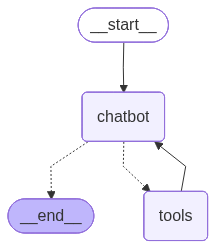

In [3]:
from IPython.display import Image, display

Image, display

try:
    display(Image(app.get_graph()
    .draw_mermaid_png()))
except Exception as e:
    print("Additional dependencies required")

# Multi Agent Systems Design

In [1]:
from typing import Annotated
import wikipedia
from langchain_core.tools import tool
import pandas as pd
import os

@tool
def wikipedia_tool(
    query: Annotated[str, "The Wikipedia search to execute to find key summary information."],
):
    """Use this to search Wikipedia for factual information."""
    try:
        # Step 1: Search using query
        results = wikipedia.search(query)
        
        if not results:
            return "No results found on Wikipedia."
        
        # Step 2: Retrieve page title
        title = results[0]

        # Step 3: Fetch summary
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False, redirect=True)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\nWikipedia summary: {summary}"

@tool
def stock_data_tool(
    company_ticker: Annotated[str, "The ticker symbol of the company to retrieve their stock performance data."], 
    num_days: Annotated[int, "The number of business days of stock data required to respond to the user query."]
) -> str:
    """
    Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.
    """
    
    # Load the CSV for the company requested
    file_path = f"data/{company_ticker}.csv"

    if os.path.exists(file_path) is False:
        return f"Sorry, but data for company {company_ticker} is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla."
    
    stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

    # Ensure the index is in date format
    stock_df.index = stock_df.index.date
    
    # Maximum num_days supported by the dataset
    max_num_days = (stock_df.index.max() - stock_df.index.min()).days
    
    if num_days > max_num_days:
        return "Sorry, but this time period exceeds the data available. Please reduce it to continue."
    
    # Get the most recent date in the DataFrame
    final_date = stock_df.index.max()

    # Filter the DataFrame to get the last num_days of stock data
    filtered_df = stock_df[stock_df.index > (final_date - pd.Timedelta(days=num_days))]

    return f"Successfully executed the stock performance data retrieval tool to retrieve the last *{num_days} days* of data for company **{company_ticker}**:\n\n{filtered_df.to_markdown()}"

from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"

<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_15574/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_15574/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_15574/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"

In [2]:
from langchain.agents import create_agent
from langchain_anthropic import ChatAnthropic

# Add three tools to the list: wikipedia_tool, stock_data_tool, and python_repl_tool
tools = [wikipedia_tool, stock_data_tool, python_repl_tool]

llm = ChatAnthropic(model="claude-haiku-4-5")

# Create an agent using the create_react_agent function
prompt = """
You are an assistant for research and analysis of Fortune 500 companies. You have access to three tools:
- A Wikipedia tool for retrieving factual summary information about companies
- A stock performance data tool for retrieving stock price information from local CSV files
- A Python tool for executing Python code, which is to be used for creating stock performance visualizations
"""

# Create an agent using the create_react_agent function
agent = create_agent(
    llm,
    tools=tools,
    system_prompt=prompt,
    name="finance_assistant"
)

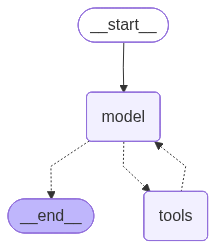

In [3]:
# Visualize your graph
agent

Update from node model:


================================== Ai Message ==================================
Name: finance_assistant

[{'text': "I'll help you find Tesla's current CEO, latest stock price, and create a plot of their closing price data.", 'type': 'text'}, {'id': 'toolu_01M1qPrXpfBXTVwrFpLevyHj', 'caller': {'type': 'direct'}, 'input': {'query': 'Tesla Inc CEO'}, 'name': 'wikipedia_tool', 'type': 'tool_use'}, {'id': 'toolu_01ASLt4QhUz7ECtMVMSVgUSu', 'caller': {'type': 'direct'}, 'input': {'company_ticker': 'TSLA', 'num_days': 252}, 'name': 'stock_data_tool', 'type': 'tool_use'}]
Tool Calls:
  wikipedia_tool (toolu_01M1qPrXpfBXTVwrFpLevyHj)
 Call ID: toolu_01M1qPrXpfBXTVwrFpLevyHj
  Args:
    query: Tesla Inc CEO
  stock_data_tool (toolu_01ASLt4QhUz7ECtMVMSVgUSu)
 Call ID: toolu_01ASLt4QhUz7ECtMVMSVgUSu
  Args:
    company_ticker: TSLA
    num_days: 252


Update from node tools:


================================= Tool Message =================================
Name: stock_dat

Python REPL can execute arbitrary code. Use with caution.


Update from node model:


================================== Ai Message ==================================
Name: finance_assistant

[{'text': 'Great! Now let me create a plot of the Tesla stock closing prices:', 'type': 'text'}, {'id': 'toolu_01UGUcF1BaXDJPypP6z7zPs5', 'caller': {'type': 'direct'}, 'input': {'code': '\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom datetime import datetime\n\n# Data from the stock data tool\ndata = {\n    \'Date\': [\'2026-03-09\', \'2026-03-06\', \'2026-03-05\', \'2026-03-04\', \'2026-03-03\', \n             \'2026-03-02\', \'2026-02-27\', \'2026-02-26\', \'2026-02-25\', \'2026-02-24\',\n             \'2026-02-23\', \'2026-02-20\', \'2026-02-19\', \'2026-02-18\', \'2026-02-17\',\n             \'2026-02-13\', \'2026-02-12\', \'2026-02-11\', \'2026-02-10\', \'2026-02-09\'],\n    \'Close\': [398.68, 396.73, 405.55, 405.94, 392.43, 403.32, 402.51, 408.58, 417.40, \n              409.38, 399.83, 411.82, 411.71, 411.32, 410.63, 417.44, 417.07, 4

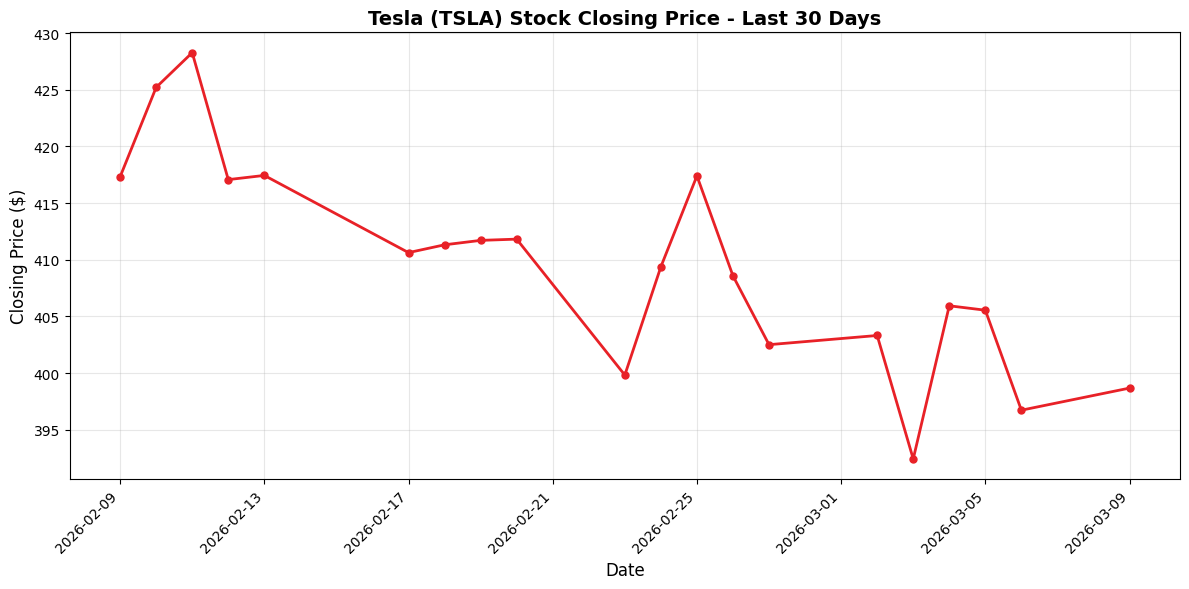

Update from node tools:


================================= Tool Message =================================
Name: python_repl_tool

Successfully executed the Python REPL tool.

Python code executed:
\`\`\`python

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Data from the stock data tool
data = {
    'Date': ['2026-03-09', '2026-03-06', '2026-03-05', '2026-03-04', '2026-03-03', 
             '2026-03-02', '2026-02-27', '2026-02-26', '2026-02-25', '2026-02-24',
             '2026-02-23', '2026-02-20', '2026-02-19', '2026-02-18', '2026-02-17',
             '2026-02-13', '2026-02-12', '2026-02-11', '2026-02-10', '2026-02-09'],
    'Close': [398.68, 396.73, 405.55, 405.94, 392.43, 403.32, 402.51, 408.58, 417.40, 
              409.38, 399.83, 411.82, 411.71, 411.32, 410.63, 417.44, 417.07, 428.27, 
              425.21, 417.32]
}

df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Create the plot
plt.figure(f

In [4]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "Tell me Tesla's current CEO, their latest stock price, and generate a plot of the closing price with the most up-to-date data you have available."}]}
):
    pretty_print_messages(chunk)

## Multi Agent SWORM

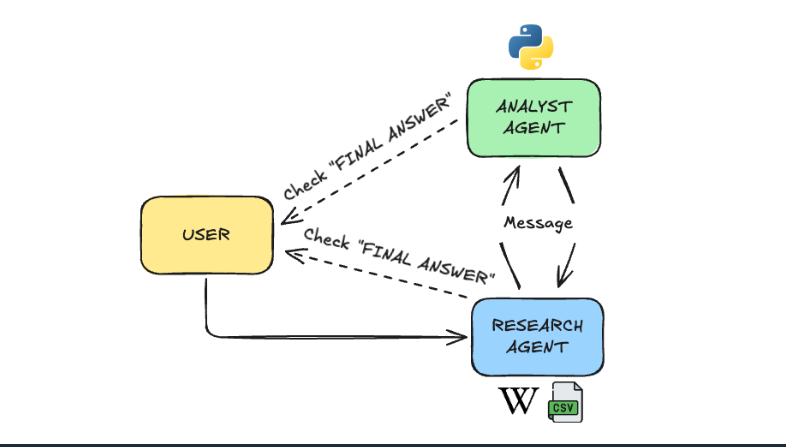

### 🐝 Starting the swarm
Let's upgrade our single-agent system to multi-agent system! We'll start with two agents arranged as a **swarm**: a researcher, that can trigger the Wikipedia tool (`wikipedia_tool()`) and stock performance data tool (`stock_data_tool()`), and a data analyst that can trigger the Python REPL tool (`python_repl_tool()`).

To get our swarm multi-agent started, we'll create a handoff tool for each agent, so it can choose to use its original toolset, or handoff to the other agent.

These tools, like the other tools we've created, need to have clear descriptions so the agent can determine the most appropriate action.

In [1]:
from typing import Annotated
import wikipedia
from langchain_core.tools import tool
import pandas as pd
import os

@tool
def wikipedia_tool(
    query: Annotated[str, "The Wikipedia search to execute to find key summary information."],
):
    """Use this to search Wikipedia for factual information."""
    try:
        # Step 1: Search using query
        results = wikipedia.search(query)
        
        if not results:
            return "No results found on Wikipedia."
        
        # Step 2: Retrieve page title
        title = results[0]

        # Step 3: Fetch summary
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False, redirect=True)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\nWikipedia summary: {summary}"

@tool
def stock_data_tool(
    company_ticker: Annotated[str, "The ticker symbol of the company to retrieve their stock performance data."], 
    num_days: Annotated[int, "The number of business days of stock data required to respond to the user query."]
) -> str:
    """
    Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.
    """
    
    # Load the CSV for the company requested
    file_path = f"data/{company_ticker}.csv"

    if os.path.exists(file_path) is False:
        return f"Sorry, but data for company {company_ticker} is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla."
    
    stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

    # Ensure the index is in date format
    stock_df.index = stock_df.index.date
    
    # Maximum num_days supported by the dataset
    max_num_days = (stock_df.index.max() - stock_df.index.min()).days
    
    if num_days > max_num_days:
        return "Sorry, but this time period exceeds the data available. Please reduce it to continue."
    
    # Get the most recent date in the DataFrame
    final_date = stock_df.index.max()

    # Filter the DataFrame to get the last num_days of stock data
    filtered_df = stock_df[stock_df.index > (final_date - pd.Timedelta(days=num_days))]

    return f"Successfully executed the stock performance data retrieval tool to retrieve the last *{num_days} days* of data for company **{company_ticker}**:\n\n{filtered_df.to_markdown()}"

from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"

<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_17264/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_17264/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_17264/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"

In [2]:
from langchain_anthropic import ChatAnthropic
from langgraph_swarm import create_handoff_tool

llm = ChatAnthropic(model="claude-haiku-4-5")

# Create a handoff tool for analyst -> researcher
transfer_to_researcher = create_handoff_tool(
    agent_name="researcher",
    description="Transfer user to the researcher assistant, who can retrieve Wikipedia summaries or load stock performance data from CSV files.",
)

# Create a handoff tool for researcher -> analyst
transfer_to_analyst = create_handoff_tool(
    agent_name="analyst",
    description="Transfer user to the analyst assistant, who can create visualizations of provided data.",
)

In [4]:
from langchain.agents import create_agent

# Create a researcher agent with access to two tools + the handoff tool
research_agent = create_agent(
    llm,
    tools=[wikipedia_tool, stock_data_tool, transfer_to_analyst],
    system_prompt="You provide summaries from Wikipedia, and can load raw, numerical stock performance data from CSV files.",
    name="researcher"
)

# Create a analyst agent with access to one tool + the handoff tool
analyst_agent = create_agent(
    llm,
    tools=[python_repl_tool, transfer_to_researcher],
    system_prompt="You generate plots of stock performance data provided by another assistant.",
    name="analyst"
)

In [5]:
from langgraph_swarm import create_swarm
from langgraph.checkpoint.memory import InMemorySaver

config = {"configurable": {"thread_id": "1", "user_id": "1"}}
checkpointer = InMemorySaver()

# Create the swarm multi-agent graph and compile it
swarm = create_swarm(
    agents=[research_agent, analyst_agent],
    default_active_agent="researcher"
).compile(checkpointer=checkpointer)

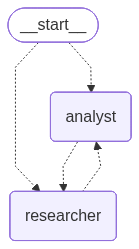

In [6]:
# Visualize your graph
swarm

In [7]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

for chunk in swarm.stream(
    {"messages": [{"role": "user", "content": "Who is Apple's CEO?"}]}, config
):
    pretty_print_messages(chunk)

Update from node researcher:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: researcher

[{'id': 'toolu_01QnmfkCMMdcWafVtMWQJtdq', 'caller': {'type': 'direct'}, 'input': {'query': 'Apple Inc CEO'}, 'name': 'wikipedia_tool', 'type': 'tool_use'}]
Tool Calls:
  wikipedia_tool (toolu_01QnmfkCMMdcWafVtMWQJtdq)
 Call ID: toolu_01QnmfkCMMdcWafVtMWQJtdq
  Args:
    query: Apple Inc CEO
================================= Tool Message =================================
Name: wikipedia_tool

Successfully executed:
Wikipedia summary: Between 1978 and 2007, there were a number of legal disputes between Apple Corps (owned by the Beatles) and the computer manufacturer Apple Computer (now Apple Inc.) over competing trademark rights, specifically over the use of the name "Apple" and their respective logos which consist of a profile of an apple. Apple Inc. paid App

## Supervisor Agents

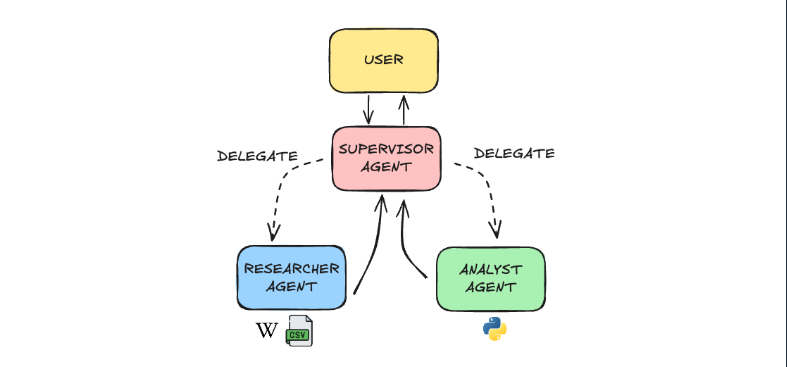

In [1]:
from typing import Annotated
import wikipedia
from langchain_core.tools import tool
import pandas as pd
import os

@tool
def wikipedia_tool(
    query: Annotated[str, "The Wikipedia search to execute to find key summary information."],
):
    """Use this to search Wikipedia for factual information."""
    try:
        # Step 1: Search using query
        results = wikipedia.search(query)
        
        if not results:
            return "No results found on Wikipedia."
        
        # Step 2: Retrieve page title
        title = results[0]

        # Step 3: Fetch summary
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False, redirect=True)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\nWikipedia summary: {summary}"

@tool
def stock_data_tool(
    company_ticker: Annotated[str, "The ticker symbol of the company to retrieve their stock performance data."], 
    num_days: Annotated[int, "The number of business days of stock data required to respond to the user query."]
) -> str:
    """
    Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.
    """
    
    # Load the CSV for the company requested
    file_path = f"data/{company_ticker}.csv"

    if os.path.exists(file_path) is False:
        return f"Sorry, but data for company {company_ticker} is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla."
    
    stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

    # Ensure the index is in date format
    stock_df.index = stock_df.index.date
    
    # Maximum num_days supported by the dataset
    max_num_days = (stock_df.index.max() - stock_df.index.min()).days
    
    if num_days > max_num_days:
        return "Sorry, but this time period exceeds the data available. Please reduce it to continue."
    
    # Get the most recent date in the DataFrame
    final_date = stock_df.index.max()

    # Filter the DataFrame to get the last num_days of stock data
    filtered_df = stock_df[stock_df.index > (final_date - pd.Timedelta(days=num_days))]

    return f"Successfully executed the stock performance data retrieval tool to retrieve the last *{num_days} days* of data for company **{company_ticker}**:\n\n{filtered_df.to_markdown()}"

from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"

<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
<>:76: SyntaxWarning: invalid escape sequence '\`'
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_17494/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_17494/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"
/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_17494/2658806078.py:76: SyntaxWarning: invalid escape sequence '\`'
  return f"

In [3]:
from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent

llm = ChatAnthropic(model="claude-haiku-4-5")

# Research agent
research_agent = create_agent(
    llm,
    tools=[wikipedia_tool, stock_data_tool],
    system_prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, including looking-up factual information and stock data. DO NOT write any code.\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="researcher"
)

# Analyst agent
analyst_agent = create_agent(
    llm,
    tools=[python_repl_tool],
    system_prompt=(
        "You are an agent that can run arbitrary Python code.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with tasks that require running code to produce an output.\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="analyst"
)

In [4]:
from langgraph_supervisor import create_supervisor
from langgraph.checkpoint.memory import InMemorySaver

config = {"configurable": {"thread_id": "1", "user_id": "1"}}
checkpointer = InMemorySaver()

supervisor = create_supervisor(
    model=llm,
    agents=[research_agent, analyst_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research and data collection tasks to this agent\n"
        "- an analyst agent. Assign the creation of visualizations via code to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile(checkpointer=checkpointer)

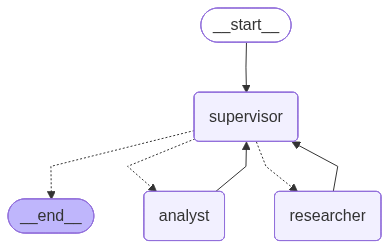

In [5]:
# Visualize your graph
supervisor

In [6]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "Who is Apple's CEO?"}]}, config
):
    pretty_print_messages(chunk)

Update from node supervisor:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: supervisor

[{'id': 'toolu_016zpfk9cXU5b7vWAZPKnxeL', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'transfer_to_researcher', 'type': 'tool_use'}]
Tool Calls:
  transfer_to_researcher (toolu_016zpfk9cXU5b7vWAZPKnxeL)
 Call ID: toolu_016zpfk9cXU5b7vWAZPKnxeL
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher


Update from node researcher:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: supervisor

[{'id': 'toolu_016zpfk9cXU5b7vWAZPKnxeL', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'transfer_to_researcher', 'type'

# Dependencies

In [7]:
# This will list everything. You can copy the lines you need.
import sys

!{sys.executable} -m pip freeze

aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
annotated-types==0.7.0
anthropic==0.84.0
anyio==4.12.1
appnope==0.1.4
asttokens==3.0.1
attrs==25.4.0
beautifulsoup4==4.14.3
certifi==2026.2.25
charset-normalizer==3.4.4
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
dataclasses-json==0.6.7
debugpy==1.8.20
decorator==5.2.1
distro==1.9.0
docstring_parser==0.17.0
executing==2.2.1
fonttools==4.62.0
frozenlist==1.8.0
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
httpx-sse==0.4.3
idna==3.11
ipykernel==7.2.0
ipython==9.11.0
ipython_pygments_lexers==1.1.1
jedi==0.19.2
jiter==0.13.0
jsonpatch==1.33
jsonpointer==3.0.0
jupyter_client==8.8.0
jupyter_core==5.9.1
kiwisolver==1.5.0
langchain==1.2.10
langchain-anthropic==1.3.4
langchain-classic==1.0.2
langchain-community==0.4.1
langchain-core==1.2.17
langchain-experimental==0.4.1
langchain-openai==1.1.10
langchain-text-splitters==1.1.1
langgraph==1.0.10
langgraph-checkpoint==4.0.1
langgraph-prebuilt==1.0.8
langgraph-sdk==0.3.9
langgraph-supervisor==0.0